# Preparacion de los datos

## Extraccion

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('datos_tratados.csv')
df = df.drop(columns=['customerID'])

print(df.shape)
print(df.columns.tolist())
df.head(3)

(7267, 21)
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total', 'CuentasDiarias']


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,CuentasDiarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333


## Encoding

In [3]:
# Identificar columnas categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [4]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Churn'])
# Excluimos Churn porque ya la encodeamos
cols_to_encode = [col for col in cat_cols if col != 'Churn']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print(df.dtypes)
df.head(3)

Churn                                    float64
SeniorCitizen                              int64
tenure                                     int64
Monthly                                  float64
Total                                    float64
CuentasDiarias                           float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

,Churn,SeniorCitizen,tenure,Monthly,Total,CuentasDiarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False


## Verificar desbalanceo

In [5]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


Al ser 73.5%/26.5% implica un desbalanceo moderado-fuerte por lo que procederemos a aplicar SMOTE

## Oversampling

In [6]:
X = df.drop(columns='Churn')
y = df['Churn']

In [7]:
#imputar con la mediana en X
X['Total'] = X['Total'].fillna(X['Total'].median())

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Antes:", y.value_counts().to_dict())
print("Después:", y_resampled.value_counts().to_dict())

Antes: {0.0: 5174, 1.0: 1869}
Después: {0.0: 5174, 1.0: 5174}


## Normalizacion

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

print("Media aproximada:", X_resampled_scaled.mean().round(2))   # debe ser ~0
print("Desviación estándar:", X_resampled_scaled.std().round(2)) # debe ser ~1

Media aproximada: -0.0
Desviación estándar: 1.0


# Correlaciones

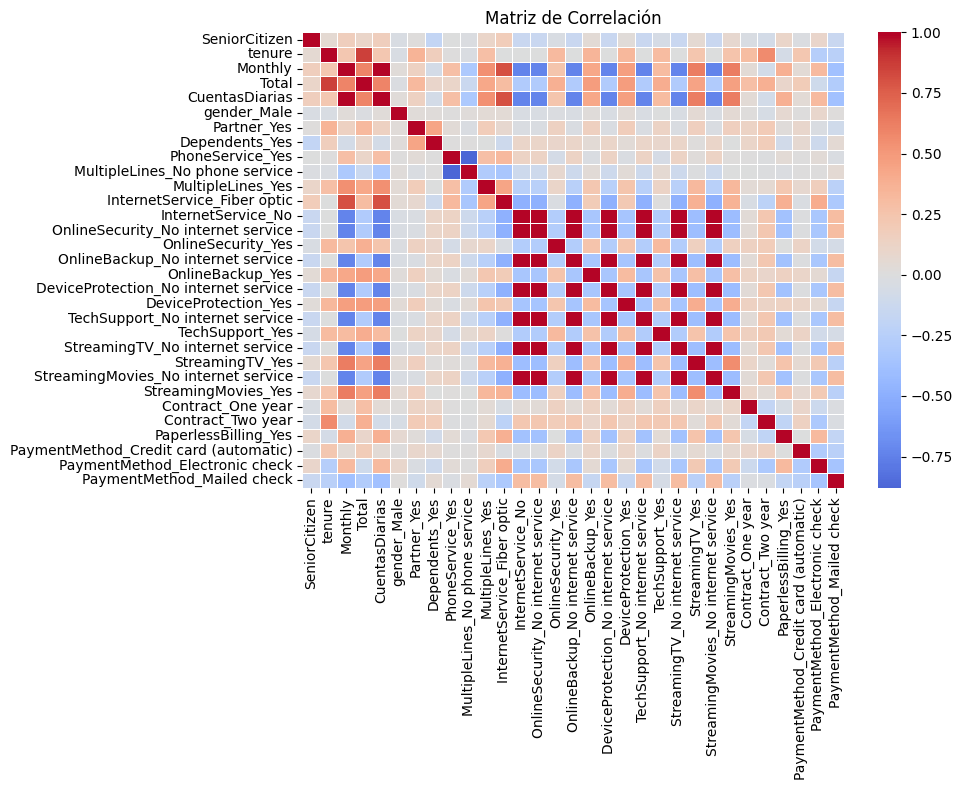

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = X_resampled.corr()

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

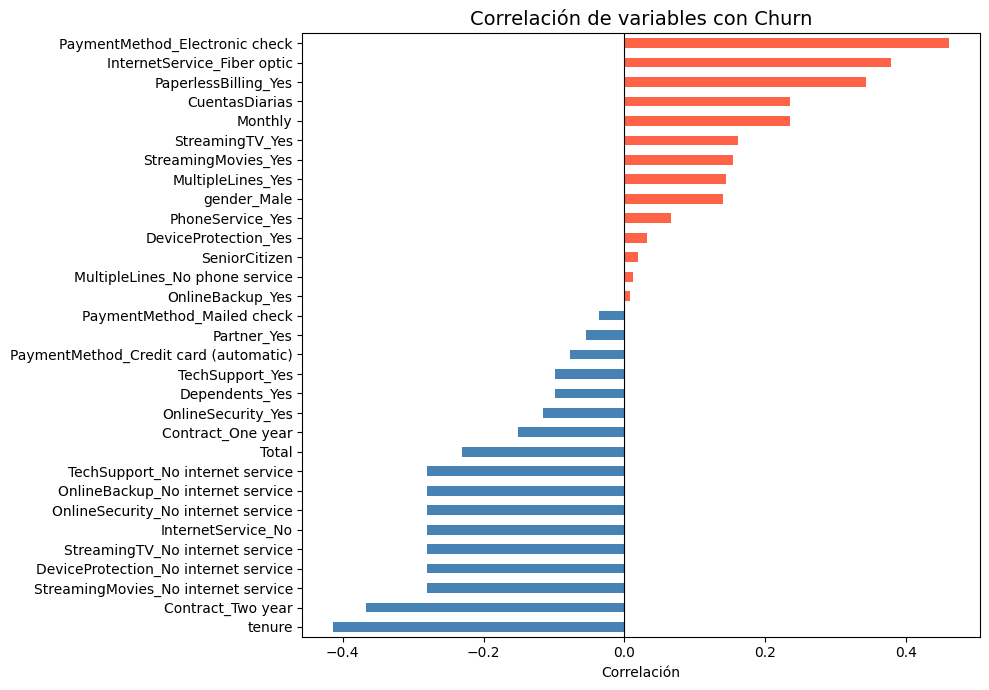

In [24]:
churn_corr = pd.DataFrame(X_resampled, columns=X.columns)
churn_corr['Churn'] = y_resampled.values

correlaciones = churn_corr.corr()['Churn'].drop('Churn').sort_values(ascending=False)

plt.figure(figsize=(10, 7))

correlaciones.sort_values().plot(
    kind='barh',
    color=['tomato' if x > 0 else 'steelblue' for x in correlaciones.sort_values()],
)

plt.title('Correlación de variables con Churn', fontsize=14)
plt.xlabel('Correlación')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11082/2132336260.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Churn', y='tenure',
/tmp/ipykernel_11082/2132336260.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No canceló', 'Canceló'])
/tmp/ipykernel_11082/2132336260.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Churn', y='Total',
/tmp/ipykernel_11082/2132336260.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No canceló', 'Canceló'])


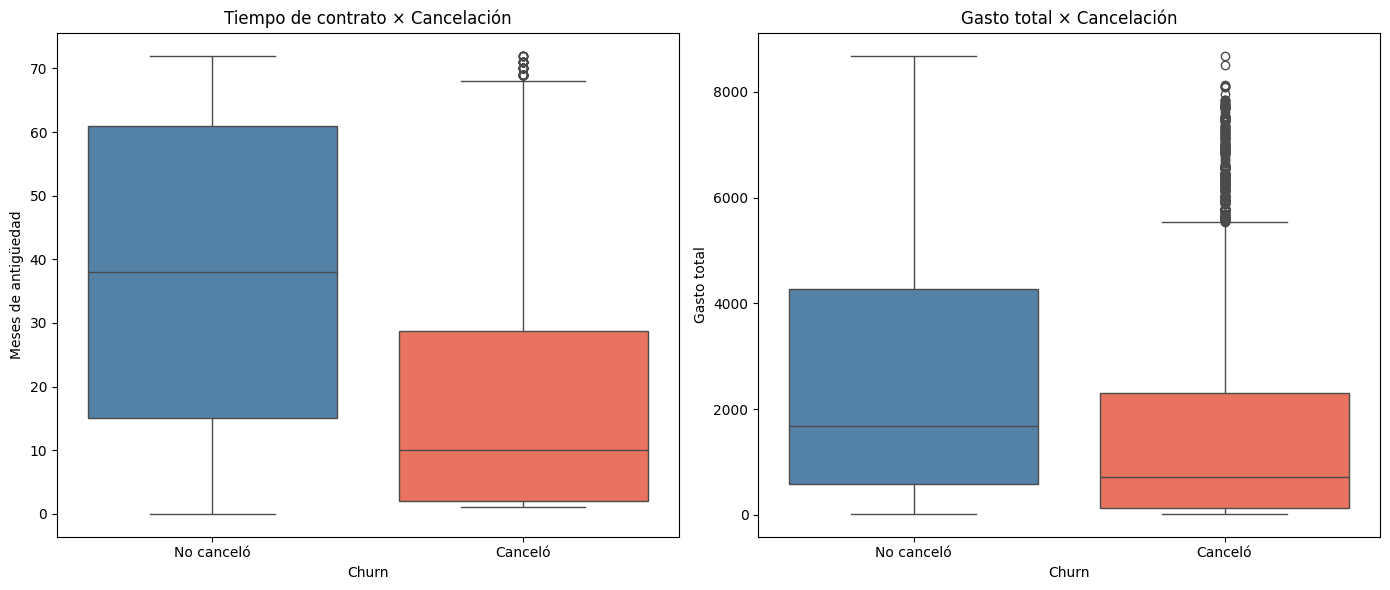

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df = X_resampled.copy()
plot_df['Churn'] = y_resampled.values

# Gráfico 1 — Tenure x Churn
sns.boxplot(data=plot_df, x='Churn', y='tenure',
            palette={'0.0': 'steelblue', '1.0': 'tomato'}, ax=axes[0])
axes[0].set_title('Tiempo de contrato × Cancelación')
axes[0].set_xticklabels(['No canceló', 'Canceló'])
axes[0].set_ylabel('Meses de antigüedad')

# Gráfico 2 — Total x Churn
sns.boxplot(data=plot_df, x='Churn', y='Total',
            palette={'0.0': 'steelblue', '1.0': 'tomato'}, ax=axes[1])
axes[1].set_title('Gasto total × Cancelación')
axes[1].set_xticklabels(['No canceló', 'Canceló'])
axes[1].set_ylabel('Gasto total')

plt.tight_layout()
plt.show()

Los clientes que más cancelan son nuevos, con fibra óptica, sin contrato fijo y que pagan con cheque electrónico. Los que más se quedan tienen contratos largos y mayor antigüedad.

Tiempo de contrato × Cancelación:\
-Clientes que no cancelaron tienen mediana de ~38 meses de antigüedad\
-Clientes que cancelaron tienen mediana de ~10 meses\
-Conclusión: Los primeros meses son críticos — si el cliente no se fideliza rápido, se va

Gasto total × Cancelación:\
-Clientes que no cancelaron tienen mediana de ~$1800 en gasto total\
-Clientes que cancelaron tienen mediana de ~$500, con muchos outliers altos\
-Conclusión: El gasto total bajo refleja que cancelaron pronto, no que pagaban menos mensualmente

Los outliers en el grupo Canceló son interesantes — hay clientes que gastaron mucho ($5000-$8500) y aún así cancelaron. Eso sugiere que el precio no es el único factor, sino también la experiencia del servicio.

# Modelado Predictivo

## Separacion de datos

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled_scaled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled  # mantiene proporción 50/50 en ambos sets
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nDistribución Train:", y_train.value_counts().to_dict())
print("Distribución Test:", y_test.value_counts().to_dict())

Train: (8278, 31)
Test: (2070, 31)

Distribución Train: {1.0: 4139, 0.0: 4139}
Distribución Test: {0.0: 1035, 1.0: 1035}


## Train Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print("Regresión Logística entrenada")

Regresión Logística entrenada


## Train Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest entrenado")

Random Forest entrenado


Aplicar normalización a Random Forest no lo perjudica, simplemente no lo beneficia. Al usar `X_resampled_scaled` para ambos mantenemos consistencia en el pipeline.

## Test

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predicciones
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Función para mostrar métricas
def evaluar_modelo(nombre, y_test, y_pred):
    print(f"{'='*40}")
    print(f"  {nombre}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print()

evaluar_modelo("Regresión Logística", y_test, y_pred_lr)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

  Regresión Logística
Accuracy:  0.8309
Precision: 0.8278
Recall:    0.8357
F1-Score:  0.8317

  Random Forest
Accuracy:  0.8493
Precision: 0.8433
Recall:    0.8580
F1-Score:  0.8506



Es mejor Random Forest que regresion logistica

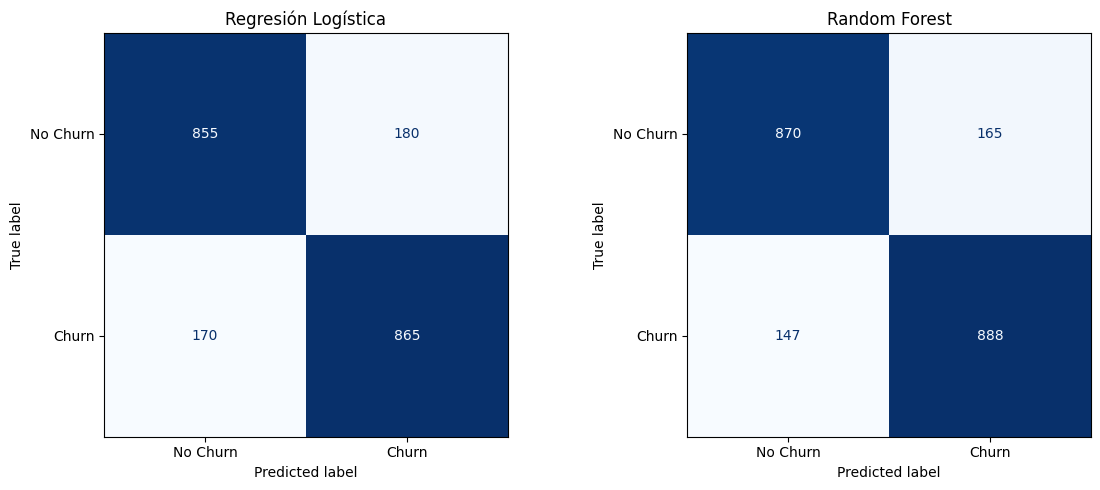

In [33]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nombre, y_pred in zip(axes, 
                               ["Regresión Logística", "Random Forest"],
                               [y_pred_lr, y_pred_rf]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

Regresión Logística:\
-855 correctos No Churn / 865 correctos Churn\
-180 falsos positivos / 170 falsos negativos\
-bastante balanceado

Random Forest:\
-870 correctos No Churn / 888 correctos Churn\
-165 falsos positivos / 147 falsos negativos\
-menos errores en ambos lados

In [40]:
print("LR Train Accuracy:", accuracy_score(y_train, lr.predict(X_train)))
print("LR Test Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("LR Diferencia:",abs(accuracy_score(y_train, lr.predict(X_train))-accuracy_score(y_test, y_pred_lr)))
print()
print("RF Train Accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("RF Test Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("LR Diferencia:",abs(accuracy_score(y_train, rf.predict(X_train))-accuracy_score(y_test, y_pred_rf)))

LR Train Accuracy: 0.8325682532012564
LR Test Accuracy:  0.8309178743961353
LR Diferencia: 0.0016503788051210888

RF Train Accuracy: 0.9986711766127084
RF Test Accuracy:  0.8492753623188406
LR Diferencia: 0.14939581429386783


Linear Regression: Diferencia mínima — el modelo generaliza perfectamente. No hay overfitting ni underfitting.

Random Forest: El modelo memoriza casi perfectamente el train (99.87%) pero baja a 84.93% en test. Diferencia de 15 puntos, esto es overfitting claro.

## Correcion de Overfitting

In [41]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limitar profundidad
    min_samples_split=10,  # mínimo de muestras para dividir
    min_samples_leaf=4,    # mínimo de muestras en hoja
    random_state=42
)
rf_tuned.fit(X_train, y_train)

print("RF Tuned Train:", accuracy_score(y_train, rf_tuned.predict(X_train)))
print("RF Tuned Test: ", accuracy_score(y_test, rf_tuned.predict(X_test)))

RF Tuned Train: 0.8686880889103649
RF Tuned Test:  0.827536231884058


In [42]:
rf_tuned2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,          # menos restrictivo que 10
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_tuned2.fit(X_train, y_train)

print("RF Tuned2 Train:", accuracy_score(y_train, rf_tuned2.predict(X_train)))
print("RF Tuned2 Test: ", accuracy_score(y_test, rf_tuned2.predict(X_test)))

RF Tuned2 Train: 0.9391157284368205
RF Tuned2 Test:  0.8468599033816425


RF Tuned2 está en el medio, menos overfitting que el original pero mejor test que el Tuned.

Para este proyecto me quedaría con el RF Original por estas razones:\
-Tiene el mejor rendimiento en test (84.93%)\
-La diferencia con Tuned2 es mínima (~0.2%)\
-En producción lo que importa es el test, no el train\
-El overfitting existe pero el modelo sigue generalizando bien\

# Interpretacion

## Importancia de Variables

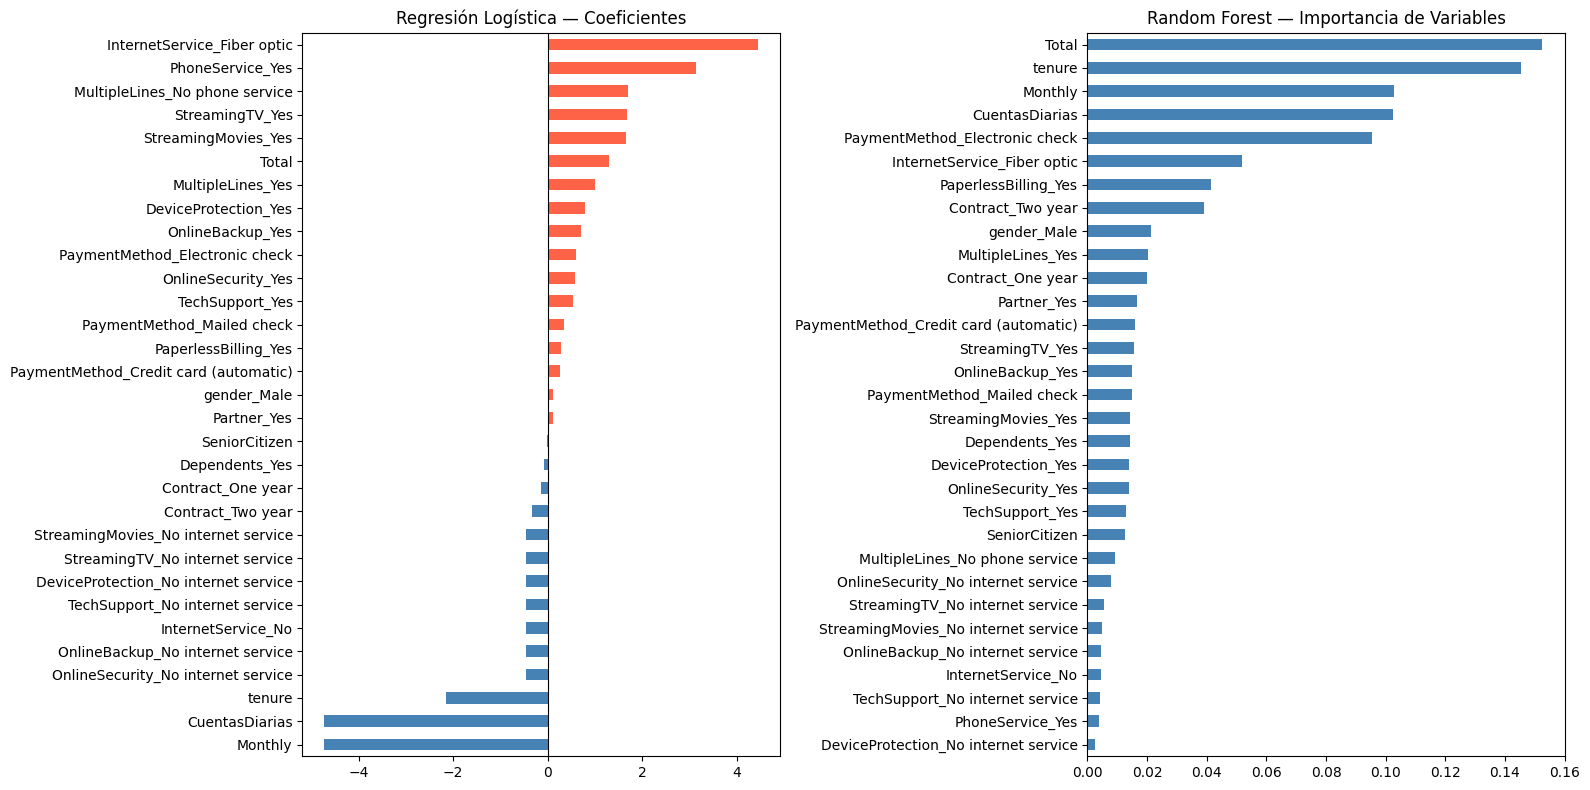

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Regresión Logística: coeficientes
coef_lr = pd.Series(lr.coef_[0], index=X.columns).sort_values()

coef_lr.plot(
    kind='barh',
    ax=axes[0],
    color=['tomato' if x > 0 else 'steelblue' for x in coef_lr]
)
axes[0].set_title('Regresión Logística — Coeficientes')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Random Forest: feature importance
importancia_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

importancia_rf.plot(
    kind='barh',
    ax=axes[1],
    color='steelblue'
)
axes[1].set_title('Random Forest — Importancia de Variables')

plt.tight_layout()
plt.show()

In [44]:
# Top 10 variables más importantes por modelo
print("=== Top 10 Regresión Logística ===")
print(coef_lr.abs().sort_values(ascending=False).head(10))

print("\n=== Top 10 Random Forest ===")
print(importancia_rf.sort_values(ascending=False).head(10))

=== Top 10 Regresión Logística ===
Monthly                           4.726727
CuentasDiarias                    4.726727
InternetService_Fiber optic       4.450725
PhoneService_Yes                  3.139225
tenure                            2.146898
MultipleLines_No phone service    1.693686
StreamingTV_Yes                   1.684216
StreamingMovies_Yes               1.652839
Total                             1.295495
MultipleLines_Yes                 1.000021
dtype: float64

=== Top 10 Random Forest ===
Total                             0.152506
tenure                            0.145469
Monthly                           0.102652
CuentasDiarias                    0.102441
PaymentMethod_Electronic check    0.095514
InternetService_Fiber optic       0.051723
PaperlessBilling_Yes              0.041496
Contract_Two year                 0.039154
gender_Male                       0.021164
MultipleLines_Yes                 0.020438
dtype: float64


Ambos modelos coinciden en el top 5

|    Variable                   |LR_Coefficient|RF_Importance|Interpretacion|
|-------------------------------|--------------|-------------|--------------|
|Monthly / CuentasDiarias       |  4.73        | 0.10        | Mayor costo mensual - más churn|
|InternetService_Fiber optic    | 4.45         | 0.05        | Fibra óptica - más churn|
|tenure                         | 2.15         | 0.15        | Más antigüedad - menos churn|
|Total                          |  1.30        | 0.15        | Gasto total alto - menos churn|
|PaymentMethod_Electronic check | 0.47         | 0.10        | E-check - más churn|

Diferencias entre modelos:\
-Regresión Logística destaca PhoneService_Yes y servicios de streaming como relevantes. Captura relaciones lineales directas.\
-Random Forest da más peso a Total y tenure. Variables continuas que capturan patrones no lineales mejor.